<a href="https://colab.research.google.com/github/indirasingh1998-ai/Digital-Microfluidics-for-CRISPR-diagnostics-of-TB/blob/main/TrainingYOLO11n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install "ultralytics<=8.3.40" supervision roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.4/212.4 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 126.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
import os
HOME = os.getcwd()

In [ ]:
!yolo segment predict model=yolo11m-seg.pt source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=true

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
100% 43.3M/43.3M [00:00<00:00, 91.7MB/s]
Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m-seg summary (fused): 330 layers, 22,396,992 parameters, 0 gradients, 113.2 GFLOPs

100% 104k/104k [00:00<00:00, 120MB/s]
image 1/1 /content/dog.jpeg: 640x384 1 person, 1 car, 1 dog, 2 backpacks, 113.4ms
Speed: 4.7ms preprocess, 113.4ms inference, 312.3ms postprocess per image at shape (1, 3, 640, 384)
Results saved to runs/segment/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from roboflow import Roboflow
rf = Roboflow(api_key="lkj0DrWJNsfOco4QeEno")
project = rf.workspace("project-aveqh").project("my-first-project-vvu4u")
version = project.version(10)
dataset = version.download("yolov11")


/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to My-First-Project-10 in yolov11:: 100%|██████████| 2604/2604 [00:00<00:00, 9107.70it/s]


In [ ]:
%cd {HOME}

!yolo task=segment mode=train model=yolo11n-seg.pt data={dataset.location}/data.yaml epochs=100 imgsz=640 plots=True    #task can also be segment, to continue you should download the last.pt file and load that as the model and data location

/content
100% 5.90M/5.90M [00:00<00:00, 80.8MB/s]
New https://pypi.org/project/ultralytics/8.3.229 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=segment, mode=train, model=yolo11n-seg.pt, data=/content/datasets/Retrain-1/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, class

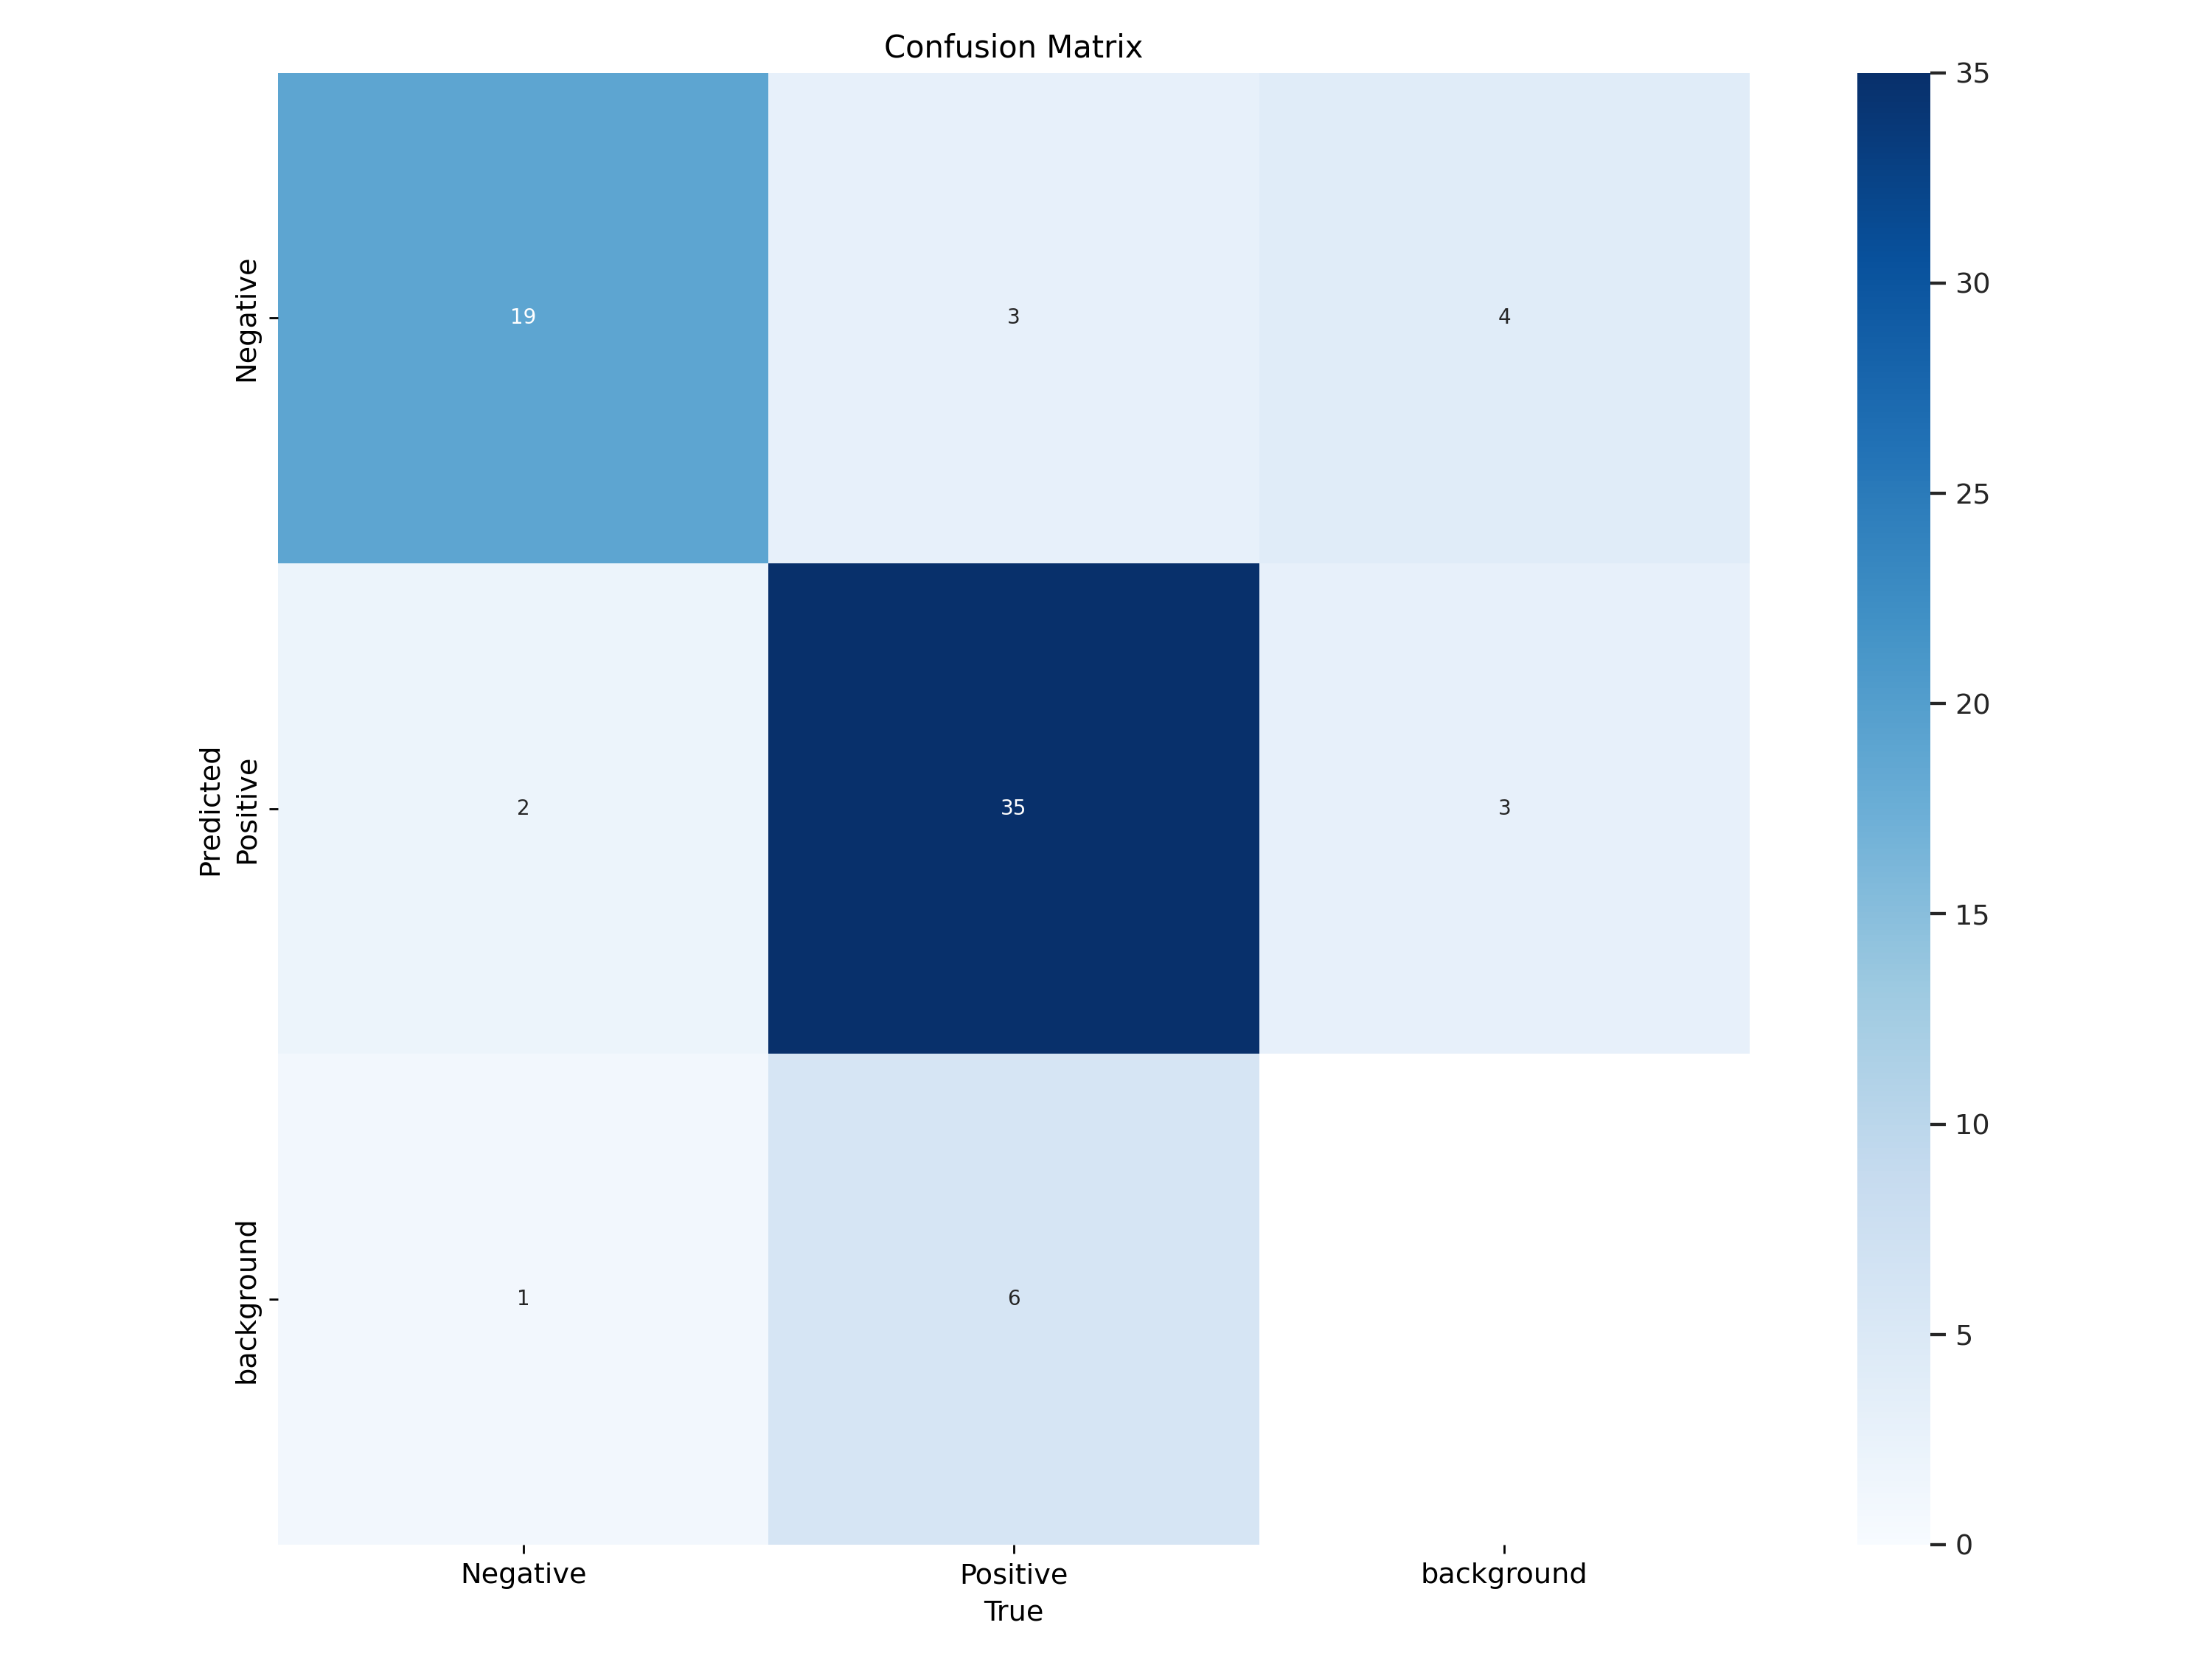

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/segment/train2/confusion_matrix.png', width=600)

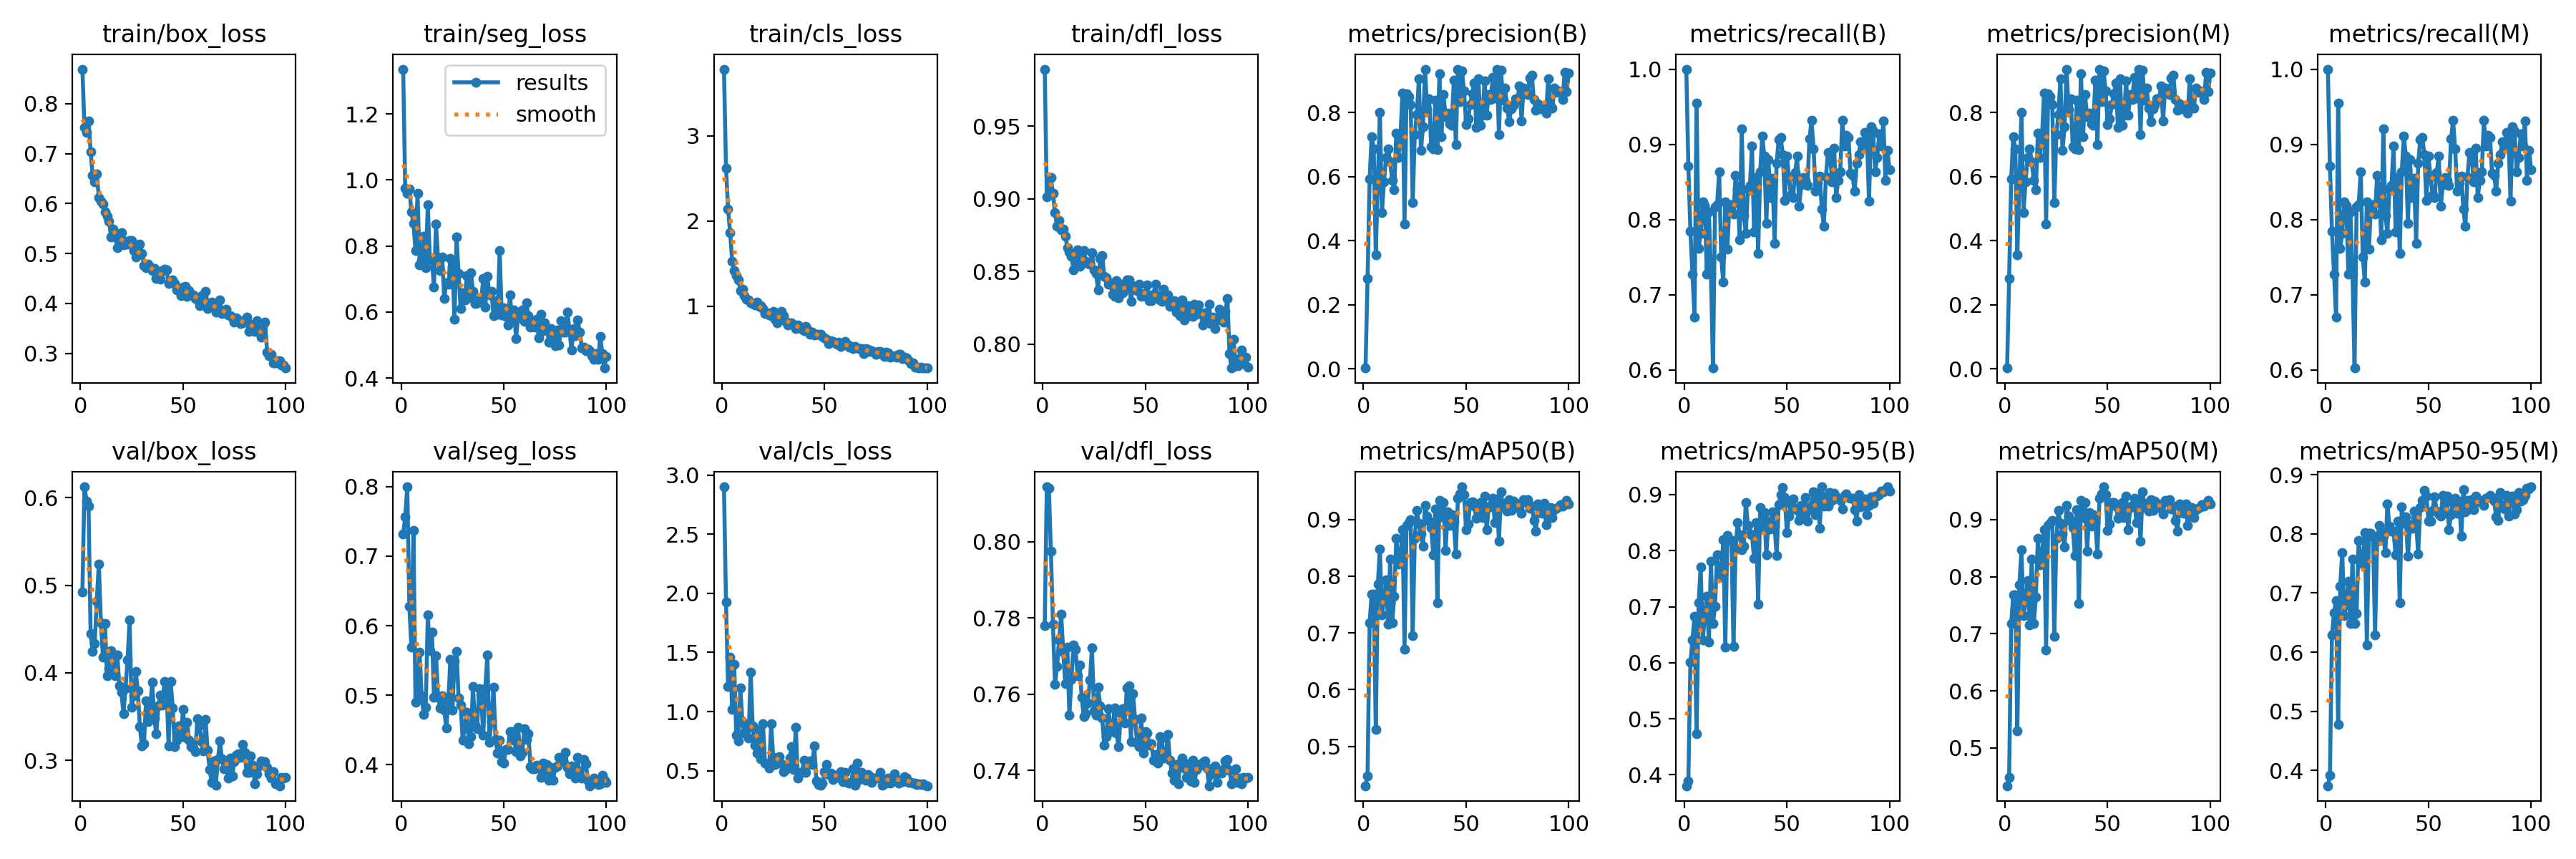

In [ ]:
IPyImage(filename=f'{HOME}/runs/segment/train2/results.png', width=600)



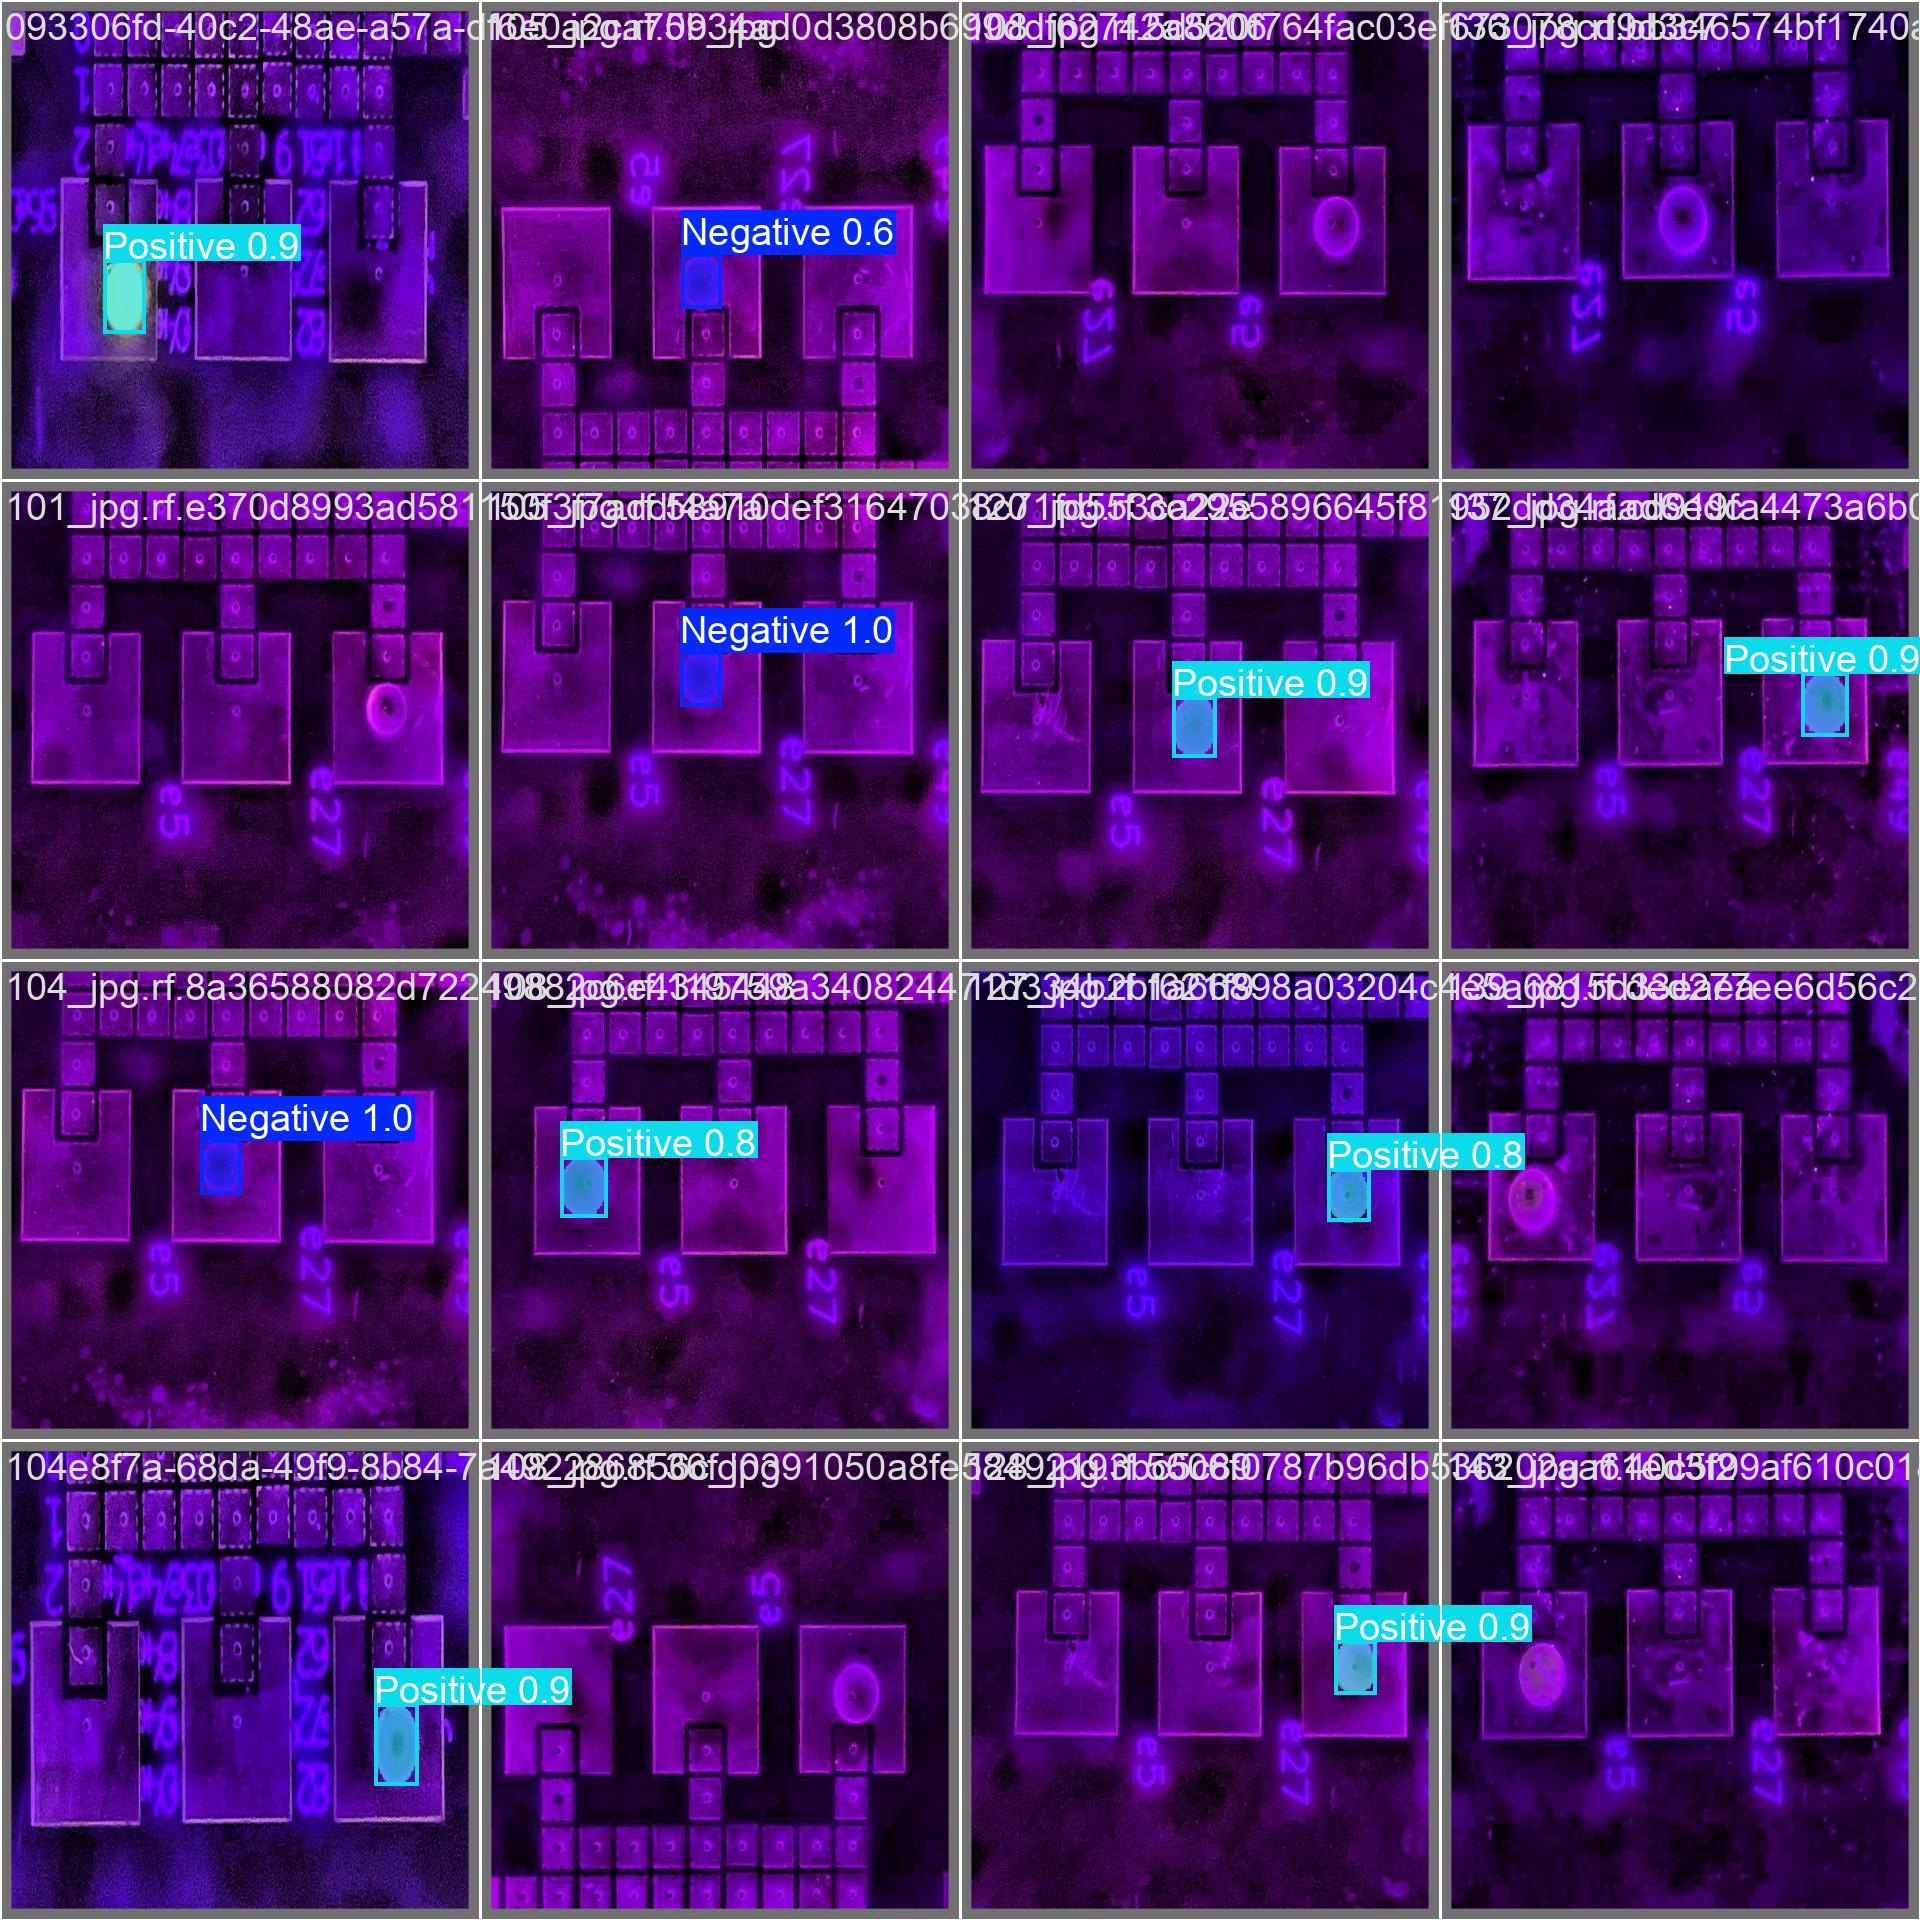

In [ ]:
IPyImage(filename=f'{HOME}/runs/segment/train2/val_batch0_pred.jpg', width=600)

In [ ]:
!yolo task=segment mode=val model={HOME}/runs/segment/train2/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n-seg summary (fused): 265 layers, 2,834,958 parameters, 0 gradients, 9.6 GFLOPs
val: Scanning /content/datasets/My-First-Project-10/valid/labels.cache... 97 images, 38 backgrounds, 0 corrupt: 100% 97/97 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% 7/7 [00:01<00:00,  3.74it/s]
                   all         97         66      0.934      0.814      0.948      0.924      0.934      0.814      0.948      0.868
              Negative         18         22      0.924      0.864      0.941       0.91      0.924      0.864      0.941      0.859
              Positive         43         44      0.944      0.764      0.954      0.938      0.944      0.764      0.954      0.877
Speed: 2.1ms preprocess, 5.9ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to runs/segment/val5
💡 Learn

In [ ]:
!yolo task=segment mode=predict model={HOME}/runs/segment/train2/weights/best.pt conf=0.25 source={dataset.location}/test/images save=true

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n-seg summary (fused): 265 layers, 2,834,958 parameters, 0 gradients, 9.6 GFLOPs

image 1/47 /content/datasets/My-First-Project-10/test/images/123_jpg.rf.e3838349b6dfa4b9e4d360f940991fef.jpg: 640x640 1 Positive, 10.8ms
image 2/47 /content/datasets/My-First-Project-10/test/images/128_jpg.rf.e9a0f97f5064fbe1058ef7f3570ccd69.jpg: 640x640 (no detections), 10.0ms
image 3/47 /content/datasets/My-First-Project-10/test/images/12_jpg.rf.8f4ab93109251b5bd5bd496b0b05243e.jpg: 640x640 (no detections), 10.6ms
image 4/47 /content/datasets/My-First-Project-10/test/images/132_jpg.rf.3a80b38bfd623b364c59eaafdd629850.jpg: 640x640 1 Positive, 9.9ms
image 5/47 /content/datasets/My-First-Project-10/test/images/134_jpg.rf.b9400534f6671b8bfde50b88a6762069.jpg: 640x640 1 Positive, 9.9ms
image 6/47 /content/datasets/My-First-Project-10/test/images/138_jpg.rf.d8d91052dce7a180ad1abc3551642419.jpg: 640x640 (no detections), 9.9

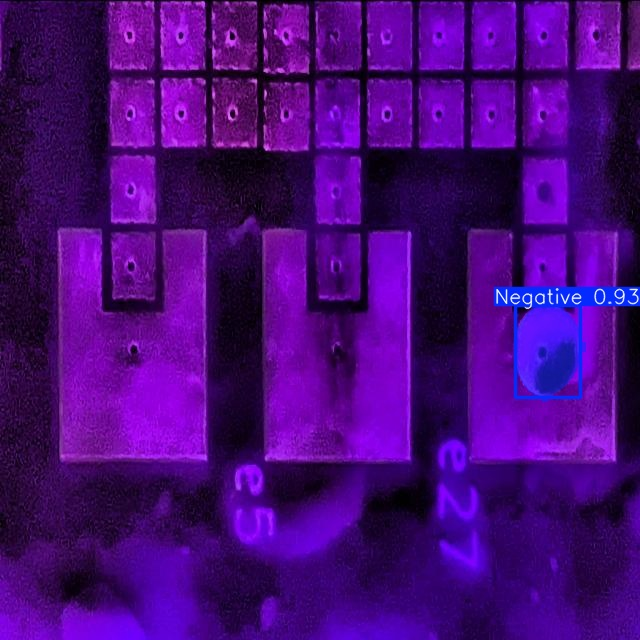

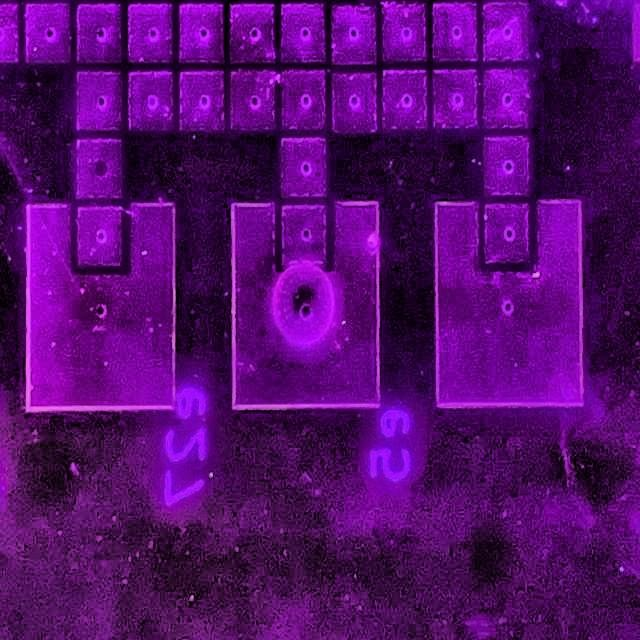

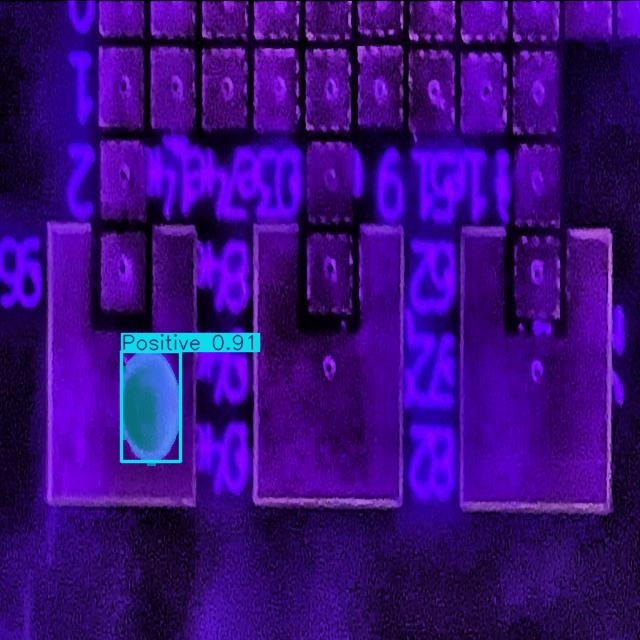

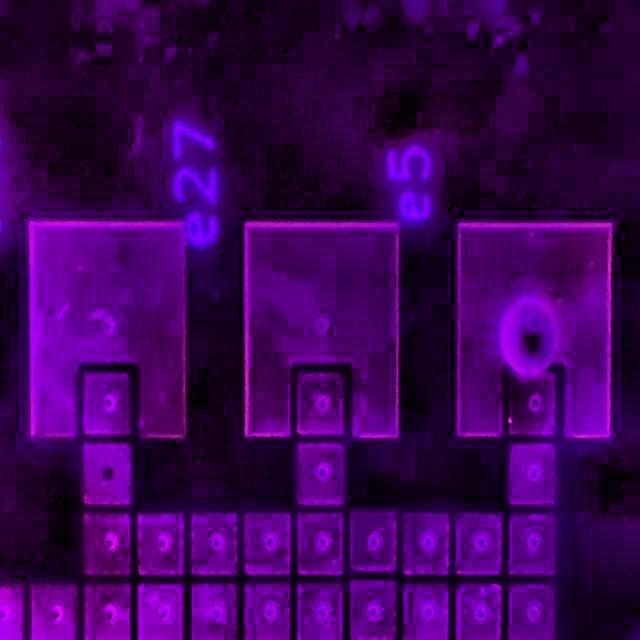

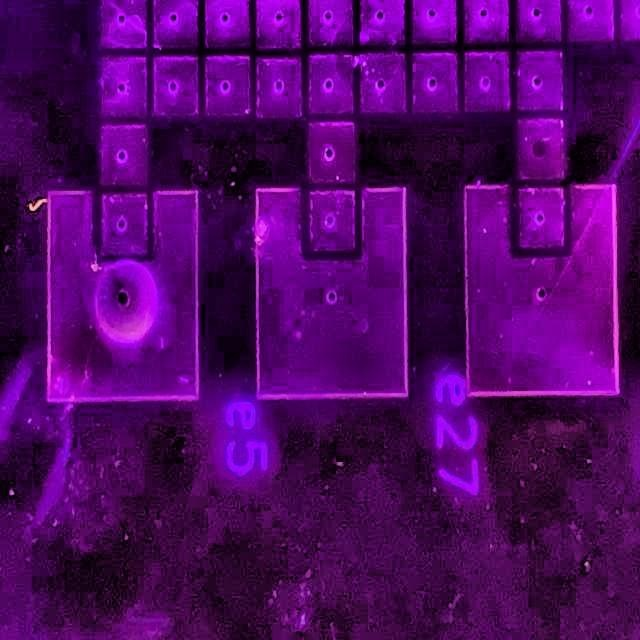

In [ ]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'{HOME}/runs/segment/predict5/*.jpg')[:5]:
      display(Image(filename=image_path, height=600))
      print("\n")

In [ ]:
!yolo task=segment mode=val model={HOME}/runs/segment/train2/weights/best.pt data={dataset.location}/data.yaml


Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n-seg summary (fused): 265 layers, 2,834,958 parameters, 0 gradients, 9.6 GFLOPs
val: Scanning /content/datasets/My-First-Project-10/valid/labels.cache... 97 images, 38 backgrounds, 0 corrupt: 100% 97/97 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% 7/7 [00:01<00:00,  3.58it/s]
                   all         97         66      0.934      0.814      0.948      0.924      0.934      0.814      0.948      0.868
              Negative         18         22      0.924      0.864      0.941       0.91      0.924      0.864      0.941      0.859
              Positive         43         44      0.944      0.764      0.954      0.938      0.944      0.764      0.954      0.877
Speed: 2.6ms preprocess, 5.8ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to runs/segment/val6
💡 Learn

In [ ]:
import os
from zipfile import ZipFile

# Replace 'your_folder_path' with the path of your folder
folder_path = "/content/runs"
zip_file = "/content/runs.zip"

# Compress the folder
with ZipFile(zip_file, 'w') as zipf:
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path, os.path.relpath(file_path, folder_path))

In [ ]:
from google.colab import files

# Download the zip file
files.download(zip_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>